# NB_T2b · LangChain/LangGraph — la même usine, framework top-level

**🏗️ Build | 🚢 Ship | 📤 Share** · ⏱️ ~75 min · LangGraph + ChatMistralAI (exécuté **en live**)

On **reprend exactement l'usine du NB_T2a** — mêmes stations, importées de
[`usine_lunettes.py`](usine_lunettes.py) — mais on l'orchestre cette fois avec **LangGraph**, le
runtime d'orchestration open-source (la « pointe » de l'écosystème LangChain), **sur des modèles
Mistral** via `ChatMistralAI`. Objectif : *sentir* la différence entre les deux moteurs. Aucune
connaissance métier requise : les stations sont de simples fonctions.

## Feuille de route
- **🏗️ Build** — modéliser l'usine en **graphe d'état explicite** (`StateGraph`) : nœuds = stations,
  arêtes = flux, **branche** (Standard/Premium), **cycle** (reprise), **HITL** (`interrupt`).
- **🚢 Ship** — un graphe compilé, **exécuté en vrai** sur les 4 commandes golden, avec persistance
  (`MemorySaver`), retries par nœud (`RetryPolicy`) et métriques.
- **📤 Share** — la grille **Mistral Workflows ↔ LangGraph** honnête : ce qui les rapproche, les sépare, quand choisir quoi.

**Pré-requis.** `pip install langgraph langchain-mistralai` (lignes 0.3.x, épinglées pour rester compatibles avec `ragas` — cf. le README de T2) ;
`MISTRAL_API_KEY` (+ `MISTRAL_SERVER_URL` pour le serveur dédié).

> **Transposition CD39.** Le graphe explicite — nœuds, branches, cycles, validation humaine — est
> exactement ce qu'on veut pour un **process métier auditable** : chaque décision de routage est
> lisible et rejouable, là où les handoffs d'un agent sont décidés par le modèle.


## 📖 Glossaire LangGraph (à garder sous les yeux)

| Terme | Définition courte |
|---|---|
| **`StateGraph`** | Le graphe d'orchestration : un **état** typé, des **nœuds** (transforment l'état), des **arêtes** (le flux). Compilé → exécutable. |
| **Nœud** *(node)* | Une fonction `état → mise à jour partielle`. Ici, une station de l'usine. |
| **Arête** *(edge)* | Une transition. `add_edge(a, b)` = fixe ; `add_conditional_edges(a, routeur, mapping)` = **routage dynamique** selon l'état. |
| **Reducer** | Fonction de **fusion** d'un champ d'état. Sans reducer, un nœud **écrase** le champ ; avec `operator.add`, il **accumule** (ex. l'historique). |
| **Cycle** | Une arête peut **revenir en arrière** (ex. `contrôle → fabrication`) : les boucles sont natives (≠ DAG figé). |
| **Checkpointer / thread** | `MemorySaver` (ou Postgres) sauvegarde l'état par `thread_id` → **persistance**, reprise. |
| **`interrupt()` / `Command(resume=…)`** | **HITL** : `interrupt()` suspend le graphe ; on reprend avec `Command(resume=valeur)`. Pendant de `wait_for_input` (NB_T2a). |
| **`RetryPolicy`** | Reprises automatiques **par nœud** : `add_node(nom, fn, retry_policy=RetryPolicy(...))`. Pendant du SLA d'activité (NB_T2a). |
| **`create_react_agent`** | Agent **ReAct** prébâti (`langgraph.prebuilt`) : un LLM + des tools, qui **décide lui-même** la séquence d'appels. |
| **Métriques** | Simples : **taux de succès**, **reprises**, **coût**, **livré à temps** (mêmes qu'en NB_T2a). |


In [ ]:
import os, operator                        # operator.add = reducer d'accumulation LangGraph
from typing import TypedDict, Annotated    # Annotated[list, operator.add] → reducer
from dotenv import load_dotenv
load_dotenv()
CLE = os.environ.get("MISTRAL_API_KEY")
URL = os.environ.get("MISTRAL_SERVER_URL")  # serveur dédié (optionnel, None sinon)


In [2]:
from langchain_mistralai import ChatMistralAI
from langchain_core.tools import tool
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import create_react_agent  # PAS langchain.agents (API 1.x)
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import interrupt, Command, RetryPolicy
import usine_lunettes as usine
from usine_lunettes import w, noter_etape   # noter_etape = helper partagé (≈ _note public)
# Gotcha serveur dédié : langchain-mistralai poste sur {base}/chat/completions → ajouter /v1
_ep = (URL.rstrip("/") + "/v1") if URL else None
llm = (ChatMistralAI(model="mistral-small-latest", mistral_api_key=CLE, endpoint=_ep, temperature=0)
       if (CLE and _ep) else
       ChatMistralAI(model="mistral-small-latest", mistral_api_key=CLE, temperature=0) if CLE else None)
print("ChatMistralAI :", "prêt" if llm else "pas de clé — cellules LLM sautées")
print(w(f"Usine : {len(usine.COMMANDES_GOLDEN)} commandes golden, stations = {list(usine.STATIONS)}", "•"))


ChatMistralAI : prêt
• Usine : 4 commandes golden, stations = ['commande', 'appro', 'fabrication', 'finition',
  'assemblage', 'controle', 'expedition']


/Users/micky/Desktop/Formation-Mistral/.venv/lib/python3.12/site-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


---

## Task 1 — Premier contact : un agent ReAct qui pilote les tools


**Pourquoi.** Point de départ le plus simple de LangChain : un **agent ReAct** — un LLM qui
**raisonne puis agit** (Reason+Act), en choisissant lui-même quels **tools** appeler et dans quel ordre.
`create_react_agent(llm, tools)` (de `langgraph.prebuilt`) le construit en une ligne.

C'est **souple** mais le routage est **décidé par le LLM** — donc peu prédictible et plus dur à auditer.
Pour une chaîne de production, on voudra un **graphe explicite** (Task 2). C'est tout l'enjeu du thème.

> **Piège.** Utiliser `langgraph.prebuilt.create_react_agent`, **pas** `langchain.agents.create_agent`
> (API LangChain 1.x, absente de la lignée 0.3.x sur laquelle on est épinglé pour préserver `ragas`).

📖 **Doc LangGraph —
[`create_react_agent`](https://langchain-ai.github.io/langgraph/reference/prebuilt/#create_react_agent)
— [`@tool`](https://python.langchain.com/docs/concepts/tools/)**


In [ ]:
# @tool expose chaque station au LLM — il choisit l'ordre d'appel lui-même.
@tool
def verifier_stock(gamme: str, quantite: int) -> dict:
    """Vérifie le stock et le MOQ pour une gamme ('standard'|'premium')."""
    return usine.approvisionner("AGENT", gamme, quantite)

@tool
def fabriquer(id_commande: str, quantite: int) -> dict:
    """Fabrique un lot. Renvoie le taux de rebut et un défaut éventuel."""
    return usine.fabriquer(id_commande, quantite)

@tool
def controler(id_commande: str, defauts: list) -> dict:
    """Contrôle qualité : rend accept / rework / scrap."""
    return usine.controler_qualite(id_commande, defauts, 0)


In [4]:
# create_react_agent : graphe LLM↔tools prébâti (Reason + Act).
# recursion_limit borne les allers-retours pour éviter une boucle infinie.
if llm:
    agent = create_react_agent(llm, [verifier_stock, fabriquer, controler])
    try:
        r = agent.invoke(
            {"messages": [{"role": "user", "content":
                "Lance CMD-DEMO en gamme standard, quantite 300 : "
                "verifie stock, fabrique, controle. Résume en 3 lignes."}]},
            {"recursion_limit": 12})
        print(w(r["messages"][-1].content, "🤖"))
    except Exception as e:
        print(w(f"agent interrompu ({type(e).__name__}: {e}) — tuyauterie validée.", "⚠️"))
else:
    print("⚠️ pas de clé — agent ReAct sauté.")


🤖 1. Vérification du stock : MOQ respecté, délai de 20 jours, coût matière de 600 €. 2.
  Fabrication : Lot fabriqué avec un taux de rebut de 7.2%. 3. Contrôle qualité : Lot accepté
  sans défauts.


**À retenir.** L'agent est pratique mais **non déterministe** : il choisit ses appels. Pour une
usine — traçabilité, reprise, branches maîtrisées — on veut **déclarer** le flux. C'est LangGraph.


---

## Task 2 — Le graphe d'état explicite (StateGraph)


**Pourquoi.** On modélise l'usine comme un **graphe d'état**. Trois ingrédients :

1. un **état** typé (`CommandeState`, un `TypedDict`) qui circule de nœud en nœud ;
2. des **nœuds** — fonctions `état → mise à jour partielle` — ici nos stations ;
3. des **arêtes** — le flux entre nœuds.

Détail clé : les **reducers**. Par défaut, `{"champ": valeur}` **écrase** le champ. Pour **accumuler**
(l'historique de toutes les étapes, reprises comprises), on annote : `Annotated[list, operator.add]`
concatène. On garde `defauts` en écrasement (remis à zéro à chaque passe) et `historique` en accumulation.

C'est le pendant **déclaratif** du `@workflow.define` de NB_T2a. On définit ici l'état, les nœuds, et
une fabrique `construire_graphe(...)` réutilisée dans les Tasks suivantes.

> **Piège.** Un nœud ne **mute** pas l'état : il **renvoie** un dict de mises à jour, que LangGraph
> fusionne via les reducers. Muter en place contourne le mécanisme de checkpoint/rejeu.

📖 **Doc LangGraph —
[`StateGraph`](https://langchain-ai.github.io/langgraph/reference/graphs/#stategraph)
— [State & reducers](https://langchain-ai.github.io/langgraph/concepts/low_level/#state)
— [Nodes](https://langchain-ai.github.io/langgraph/concepts/low_level/#nodes)**


In [ ]:
# CommandeState : le "contrat de données" qui circule de nœud en nœud.
# Chaque nœud reçoit l'état complet et renvoie un dict PARTIEL.
# Doc : https://langchain-ai.github.io/langgraph/concepts/low_level/#state
class CommandeState(TypedDict):
    id: str; gamme: str; quantite: int; profil: str; echeance_jours: int
    tentative: int
    defauts: list                              # écrasé à chaque passe (pas de reducer)
    verdict: str
    a_temps: object                            # bool ou None si non expédiée
    historique: Annotated[list, operator.add]  # accumulé sur toutes les passes (reducer +)
    kpis: dict

def etat0(c):
    """État initial d'une commande golden (tentative 0, listes vides)."""
    return {"id": c.id, "gamme": c.gamme, "quantite": c.quantite, "profil": c.profil,
            "echeance_jours": c.echeance_jours, "tentative": 0, "defauts": [], "verdict": "",
            "a_temps": None, "historique": []}


In [ ]:
# Chaque nœud : (état: CommandeState) → dict partiel. LangGraph fusionne via reducers.
# Les nœuds ne mutent JAMAIS l'état — ils renvoient un dict.
def n_commande(s):
    """Nœud réception : valide la commande."""
    r = usine.recevoir_commande(s["id"], s["gamme"], s["quantite"])
    return {"historique": [noter_etape("commande", r)]}  # noter_etape : helper partagé usine_lunettes

def n_appro(s):
    """Nœud appro : réconcilie MOQ + délai."""
    r = usine.approvisionner(s["id"], s["gamme"], s["quantite"])
    return {"historique": [noter_etape("appro", r)]}

def n_fabrication(s):
    """Nœud fabrication : réinitialise les défauts, produit, journalise."""
    r = usine.fabriquer(s["id"], s["quantite"], s["tentative"], s["profil"])
    return {"defauts": [r["defaut"]] if r["defaut"] else [],  # reset : pas de reducer sur defauts
            "historique": [noter_etape("fabrication", r)]}


In [ ]:
def n_finition(s):
    """Nœud finition (Premium uniquement) : empile le défaut éventuel."""
    r = usine.finition_premium(s["id"], s["tentative"])
    return {"defauts": s["defauts"] + ([r["defaut"]] if r["defaut"] else []),
            "historique": [noter_etape("finition", r)]}

def n_assemblage(s):
    """Nœud assemblage : empile le défaut éventuel."""
    r = usine.assembler(s["id"], s["tentative"])
    return {"defauts": s["defauts"] + ([r["defaut"]] if r["defaut"] else []),
            "historique": [noter_etape("assemblage", r)]}

def n_controle(s):
    """Nœud contrôle qualité : fixe le verdict accept | rework | scrap."""
    qc = usine.controler_qualite(s["id"], s["defauts"], s["tentative"])
    return {"verdict": qc["verdict"],
            "historique": [noter_etape("controle", {"ok": qc["verdict"] == "accept"})]}


In [ ]:
def n_rework(s):
    """Nœud reprise : incrémente la tentative avant de reboucler sur fabrication."""
    return {"tentative": s["tentative"] + 1}  # la boucle est dans la topologie, pas ici

def n_expedition(s):
    """Nœud expédition : calcule 'livré à temps'."""
    r = usine.expedier(s["id"], s["quantite"], usine.DELAI_APPRO_JOURS[s["gamme"]], s["echeance_jours"])
    return {"a_temps": r["livre_a_temps"], "historique": [noter_etape("expedition", r)]}

def n_metriques(s):
    """Nœud métriques : agrège taux de succès / coût / délai."""
    return {"kpis": usine.calcul_metriques(s["historique"], s["quantite"])}

def n_hitl(s):
    """Nœud HITL : suspend le graphe si le délai d'appro dépasse l'échéance."""
    if usine.DELAI_APPRO_JOURS[s["gamme"]] > s["echeance_jours"]:
        # interrupt() suspend le graphe — reprise via Command(resume=...) + même thread_id
        decision = interrupt({"commande": s["id"], "question": "Délai appro > échéance : expédier ?"})
        return {"historique": [noter_etape("hitl", {"ok": decision == "expedite"})]}
    return {}


In [ ]:
# Les routes sont des fonctions état → str branchées sur add_conditional_edges.
# Elles décident du prochain nœud sans connaître la topologie — pur calcul sur l'état.
# Doc : https://langchain-ai.github.io/langgraph/concepts/low_level/#conditional-edges
def route_gamme(s):
    """'premium' → finition | 'standard' → assemblage."""
    return s["gamme"]  # la valeur doit correspondre à une clé du mapping

def route_qc(s):
    """'accept' → expédition | 'rework' → reprise | 'scrap' → métriques directement."""
    return s["verdict"]


In [ ]:
def construire_graphe(checkpointer=None, avec_hitl=False, avec_retry=False):
    """Fabrique réutilisée dans toutes les Tasks. Compile le graphe LangGraph.

    Parameters
    ----------
    checkpointer : BaseCheckpointSaver, optional
        MemorySaver() active la persistance par thread_id (requis pour interrupt).
    avec_hitl : bool, default False
        Insère le nœud HITL entre contrôle accepté et expédition.
    avec_retry : bool, default False
        Attache RetryPolicy(max_attempts=3) au nœud fabrication.
    """
    g = StateGraph(CommandeState)
    # ── Nœuds ─────────────────────────────────────────────────────────────────
    g.add_node("commande",    n_commande)
    g.add_node("appro",       n_appro)
    g.add_node("fabrication", n_fabrication,
               retry_policy=RetryPolicy(max_attempts=3) if avec_retry else None)
    g.add_node("finition",    n_finition)
    g.add_node("assemblage",  n_assemblage)
    g.add_node("controle",    n_controle)
    g.add_node("rework",      n_rework)
    g.add_node("expedition",  n_expedition)
    g.add_node("metriques",   n_metriques)
    # ── Arêtes fixes ──────────────────────────────────────────────────────────
    g.add_edge(START,        "commande")     # entrée du graphe
    g.add_edge("commande",   "appro")        # réception → appro (séquentiel)
    g.add_edge("appro",      "fabrication")
    # ── Branche gamme ─────────────────────────────────────────────────────────
    g.add_conditional_edges("fabrication", route_gamme,
                            {"premium": "finition", "standard": "assemblage"})
    g.add_edge("finition",   "assemblage")
    g.add_edge("assemblage", "controle")
    # ── Verdict QC : accept | rework (cycle) | scrap ──────────────────────────
    # Doc cycles : https://langchain-ai.github.io/langgraph/concepts/low_level/#cycles
    if avec_hitl:
        g.add_node("hitl", n_hitl)
        g.add_conditional_edges("controle", route_qc,
                                {"accept": "hitl", "rework": "rework", "scrap": "metriques"})
        g.add_edge("hitl",      "expedition")
    else:
        g.add_conditional_edges("controle", route_qc,
                                {"accept": "expedition", "rework": "rework", "scrap": "metriques"})
    g.add_edge("rework",     "fabrication")  # ← le CYCLE : retour en arrière natif LangGraph
    g.add_edge("expedition", "metriques")
    g.add_edge("metriques",  END)
    return g.compile(checkpointer=checkpointer)


In [11]:
graphe = construire_graphe()              # sans HITL, sans retry
c      = usine.COMMANDES_GOLDEN[0]        # CMD-001 : standard nominale
fin    = graphe.invoke(etat0(c))
print(w(f"[{c.id}] verdict={fin['verdict']} "
        f"étapes={[h['station'] for h in fin['historique']]}", "✅"))


✅ [CMD-2026-001] verdict=accept étapes=['commande', 'appro', 'fabrication', 'assemblage',
  'controle', 'expedition']


**À retenir.** Le flux est **déclaré** (`add_edge`, `add_conditional_edges`) : on lit le pipeline
d'un coup d'œil, chaque exécution est traçable. Les nœuds sont **déterministes** (le LLM n'intervient
pas dans le routage) — l'inverse de l'agent ReAct de la Task 1.


---

## Task 3 — Branche conditionnelle : Standard vs Premium


**Pourquoi.** Une **arête conditionnelle** aiguille selon l'état :
`add_conditional_edges("fabrication", route_gamme, {"premium": "finition", "standard": "assemblage"})`.
La Premium passe par une **étape de finition** ; la Standard va directement à l'assemblage. C'est le
pendant du `router_gamme` de NB_T2a — mais **visible dans la structure du graphe**. On lance une
commande **Premium** : elle passe par la finition.

📖 **Doc LangGraph — [Conditional edges](https://langchain-ai.github.io/langgraph/concepts/low_level/#conditional-edges)**


In [12]:
c = usine.COMMANDES_GOLDEN[2]                 # premium (profil casse → scrap attendu)
fin = graphe.invoke(etat0(c))
print(w(f"[{c.id}] gamme={c.gamme} verdict={fin['verdict']} defauts={fin['defauts']}", "•"))
print(w(f"chemin = {[h['station'] for h in fin['historique']]}", "  "))
print(w("→ la Premium est bien passée par 'finition' (que la Standard saute).", "✅"))


• [CMD-2026-003] gamme=premium verdict=scrap defauts=['piece_cassee']
   chemin = ['commande', 'appro', 'fabrication', 'finition', 'assemblage', 'controle']
✅ → la Premium est bien passée par 'finition' (que la Standard saute).


---

## Task 4 — Le cycle : échec contrôle → reprise (rework loop)


**Pourquoi.** Les **cycles** sont natifs en LangGraph (≠ DAG figé) : une arête conditionnelle
peut **revenir en arrière**. Ici `contrôle --rework--> rework --> fabrication` reboucle tant que le
contrôle ne tranche pas `accept`/`scrap`. Le compteur `tentative` (incrémenté par `n_rework`) garantit
la **terminaison**. On lance CMD-002 (défaut réparable) : passe 0 → rework, passe 1 → accept.

> **Piège.** Un cycle sans condition de sortie = boucle infinie. La sortie est portée par la logique du
> contrôle (`tentative_qc`), pas par le graphe : le graphe autorise le cycle, la règle métier l'arrête.

📖 **Doc LangGraph — [Cycles](https://langchain-ai.github.io/langgraph/concepts/low_level/#cycles)**


In [13]:
c = usine.COMMANDES_GOLDEN[1]                 # premium, défaut réparable → rework → accept
fin = graphe.invoke(etat0(c))
passes = [h for h in fin["historique"] if h["station"] == "controle"]
print(w(f"[{c.id}] verdict final={fin['verdict']} — passages contrôle={len(passes)} "
        f"(tentative finale={fin.get('tentative', 0)})", "✅"))
print(w(f"chemin = {[h['station'] for h in fin['historique']]}", "  "))


✅ [CMD-2026-002] verdict final=accept — passages contrôle=2 (tentative finale=1)
   chemin = ['commande', 'appro', 'fabrication', 'finition', 'assemblage', 'controle',
   'fabrication', 'finition', 'assemblage', 'controle', 'expedition']


---

## Task 5 — Persistance + Human-in-the-loop (interrupt / resume)


**Pourquoi.** Pour un point de **validation humaine**, LangGraph combine :

- un **checkpointer** (`MemorySaver`, ou Postgres en prod) : l'état est **sauvegardé** après chaque
  super-étape, indexé par un **`thread_id`** → graphe **reprenable** ;
- **`interrupt(payload)`** : dans un nœud, suspend le graphe et **rend la main** au client. On **reprend**
  en ré-invoquant avec `Command(resume=valeur)` (même `thread_id`).

Pendant exact du `wait_for_input` de NB_T2a. On l'exerce sur la commande **urgente** (délai appro > échéance).

> **Piège.** `interrupt()` exige un checkpointer **et** un `thread_id` : sans état persistant, impossible
> de suspendre puis reprendre.

📖 **Doc LangGraph —
[`interrupt`](https://langchain-ai.github.io/langgraph/reference/types/#langgraph.types.interrupt)
— [`Command`](https://langchain-ai.github.io/langgraph/reference/types/#langgraph.types.Command)
— [`MemorySaver`](https://langchain-ai.github.io/langgraph/reference/checkpoints/)**


In [14]:
g_hitl = construire_graphe(checkpointer=MemorySaver(), avec_hitl=True)
c   = usine.COMMANDES_GOLDEN[3]                 # standard urgente → déclenche le HITL
cfg = {"configurable": {"thread_id": c.id}}     # thread_id identifie l'état persistant de CETTE commande

etat = g_hitl.invoke(etat0(c), cfg)             # s'arrête sur interrupt → payload __interrupt__
itr  = etat.get("__interrupt__")
print(w(f"[{c.id}] graphe suspendu → {itr[0].value if itr else 'pas d_interruption'}", "⏸"))

# Décision humaine : on reprend le MÊME thread avec Command(resume=...)
fin = g_hitl.invoke(Command(resume="expedite"), cfg)
print(w(f"[{c.id}] repris → verdict={fin['verdict']} a_temps={fin.get('a_temps')}", "✅"))


⏸ [CMD-2026-004] graphe suspendu → {'commande': 'CMD-2026-004', 'question': 'Délai appro >
  échéance : expédier ?'}
✅ [CMD-2026-004] repris → verdict=accept a_temps=False


---

## Task 6 — Superviseur : une décision arbitrée par le LLM


**Pourquoi.** Sur une mise au rebut, un **superviseur** LLM peut expliquer la décision en
langage naturel et proposer une action corrective. On garde le LLM pour ce qu'il fait de mieux
(raisonnement/synthèse), **pas** pour le routage (déclaré dans le graphe). Un vrai multi-agents
utiliserait `Command(goto=…)` pour un **handoff** entre nœuds-agents.

📖 **Doc LangGraph — [Multi-agent / handoffs](https://langchain-ai.github.io/langgraph/concepts/multi_agent/)**


In [15]:
c   = usine.COMMANDES_GOLDEN[2]               # rebut (pièce cassée)
fin = graphe.invoke(etat0(c))
if llm and fin["verdict"] == "scrap":
    try:
        msg = llm.invoke(
            f"Tu es superviseur d'une usine. La commande {c.id} est mise au rebut pour les défauts "
            f"{fin['defauts']}. En 2 phrases : cause probable et action corrective.")
        print(w(msg.content, "🧑‍🏭"))
    except Exception as e:
        print(w(f"appel superviseur interrompu ({type(e).__name__}) — verdict scrap confirmé par le graphe.", "⚠️"))
else:
    print(w(f"verdict={fin['verdict']} (superviseur LLM sauté si pas de clé).", "•"))


🧑‍🏭 **Cause probable** : La pièce cassée pourrait être due à un défaut de fabrication, une
    surcharge mécanique ou une usure prématurée des outils de production.  **Action
    corrective** : Renforcer les contrôles qualité en amont, inspecter les outils et ajuster
    les paramètres de production pour éviter les contraintes excessives.


---

## Task 7 — Robustesse (RetryPolicy) + métriques sur les 4 commandes


**Pourquoi.** `add_node(..., retry_policy=RetryPolicy(...))` donne à un nœud des **reprises
automatiques** (pendant transparent du SLA d'activité de NB_T2a). On recompile avec retries, on exécute
les **4 commandes golden** et on lit les **mêmes métriques** que NB_T2a — preuve que c'est **la même
usine**, pilotée par un autre moteur.

📖 **Doc LangGraph — [`RetryPolicy`](https://langchain-ai.github.io/langgraph/reference/types/#langgraph.types.RetryPolicy)**


In [ ]:
g_final       = construire_graphe(avec_retry=True)  # RetryPolicy sur le nœud fabrication
resultats_t1b = []
for c in usine.COMMANDES_GOLDEN:
    fin  = g_final.invoke(etat0(c))
    k    = fin["kpis"]
    hitl = usine.DELAI_APPRO_JOURS[c.gamme] > c.echeance_jours  # délai appro > échéance ?
    resultats_t1b.append({"id": c.id, "gamme": c.gamme, "verdict": fin["verdict"],
                          "reprises": fin.get("tentative", 0), "hitl": hitl,
                          "a_temps": fin.get("a_temps"), "kpis": k,
                          "parcours": fin["historique"]})   # "parcours" = clé attendue par usine_viz


In [17]:
for r in resultats_t1b:
    flag   = "✅" if r["verdict"] == "accept" else "❌"
    bribes = f"reprises={r['reprises']}"
    if r["hitl"]:              bribes += " ⏸HITL"
    if r["a_temps"] is False:  bribes += " ⏰retard"
    print(w(f"{r['id']:14} [{r['gamme']:8}] {r['verdict']:7} {bribes} "
            f"succès={r['kpis']['taux_succes']} coût={r['kpis']['cout_eur']}€", flag))
ok = sum(1 for r in resultats_t1b if r["verdict"] == "accept")
print(w(f"Bilan : {ok}/{len(resultats_t1b)} acceptées — même usine, autre moteur.", "📊"))


✅ CMD-2026-001   [standard] accept  reprises=0 succès=1.0 coût=5.6€
✅ CMD-2026-002   [premium ] accept  reprises=1 succès=0.818 coût=11.0€
❌ CMD-2026-003   [premium ] scrap   reprises=0 ⏸HITL succès=0.667 coût=6.4€
✅ CMD-2026-004   [standard] accept  reprises=0 ⏸HITL ⏰retard succès=0.833 coût=5.6€
📊 Bilan : 3/4 acceptées — même usine, autre moteur.


---

## Task 8 — Visualiser le graphe et l'usine


**Pourquoi.** LangGraph sait **dessiner son propre graphe** : on visualise donc le *vrai* graphe
compilé (via `get_graph()`), puis 6 vues identiques à NB_T2a — **topologie, trajectoires, métriques,
coûts, Gantt, entonnoir** — via le module [`usine_viz.py`](usine_viz.py). Point clé : `get_graph()`
donne les nœuds et arêtes **tels qu'ils s'exécutent réellement** (≠ T1a qui dessinait un schéma manuel).


In [ ]:
import matplotlib.pyplot as plt
import usine_viz as viz
gg    = construire_graphe(avec_hitl=True).get_graph()   # topologie RÉELLE du graphe compilé
edges = [(e.source, e.target,
          e.data if isinstance(getattr(e, "data", None), str) else "")
         for e in gg.edges]                              # e.data = label arête conditionnelle
cols  = {}
for n in gg.nodes:
    if n in ("controle", "hitl"):                    cols[n] = viz.ORANGE  # décision
    elif n == "expedition":                           cols[n] = viz.VERT    # sortie OK
    elif n in ("metriques", "__start__", "__end__"): cols[n] = viz.GRIS    # technique
    else:                                            cols[n] = viz.BLEU    # traitement


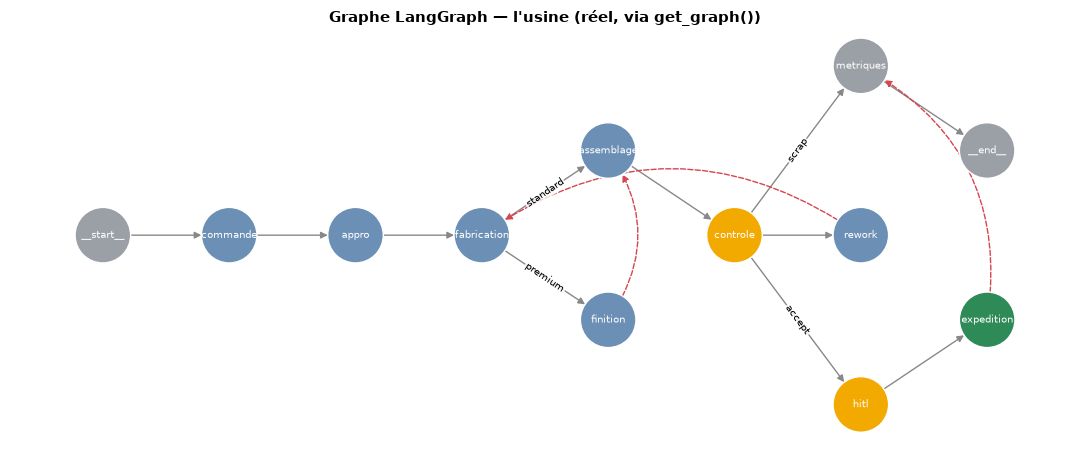

In [19]:
viz.dessiner_topologie(edges, "Graphe LangGraph — l'usine (réel, via get_graph())",
                       source="__start__", couleurs_noeuds=cols)
plt.show()


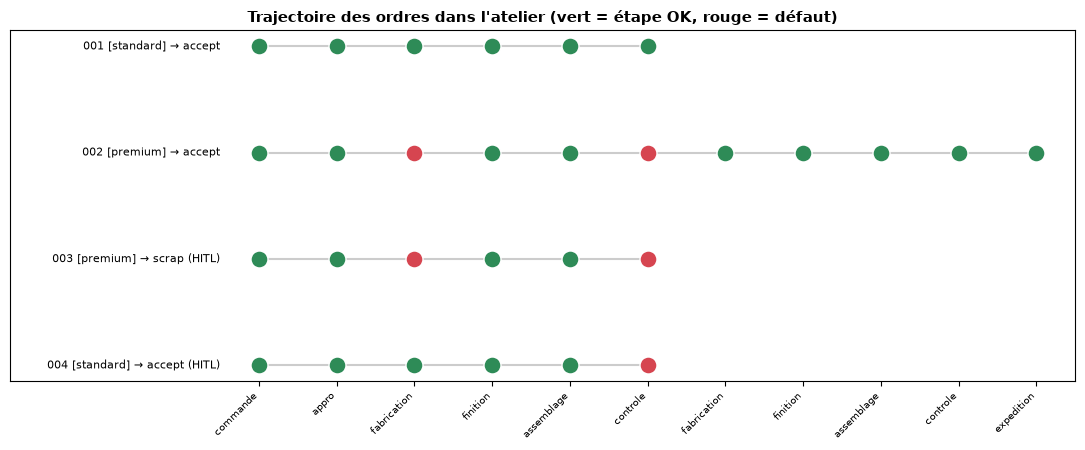

In [20]:
# Trajectoire de chaque commande (la reprise de CMD-002 : contrôle franchi 2 fois)
viz.dessiner_trajectoires(resultats_t1b)
plt.show()


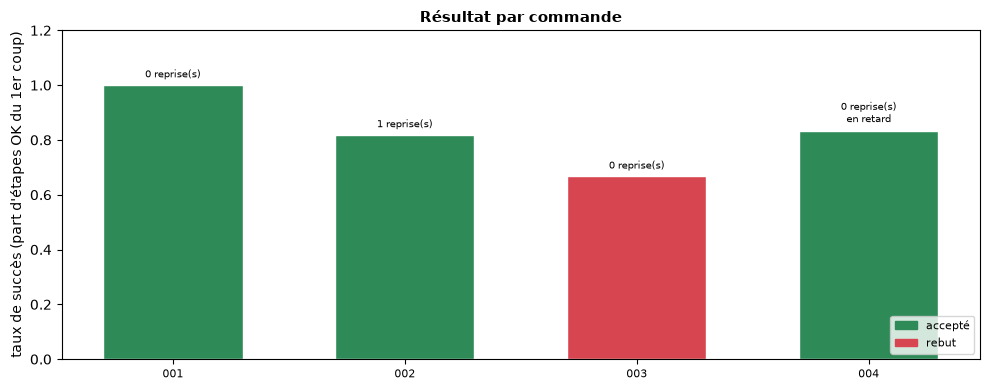

In [21]:
# Résultat par commande — mêmes métriques que NB_T2a (même usine, autre moteur)
viz.dessiner_kpis(resultats_t1b)
plt.show()


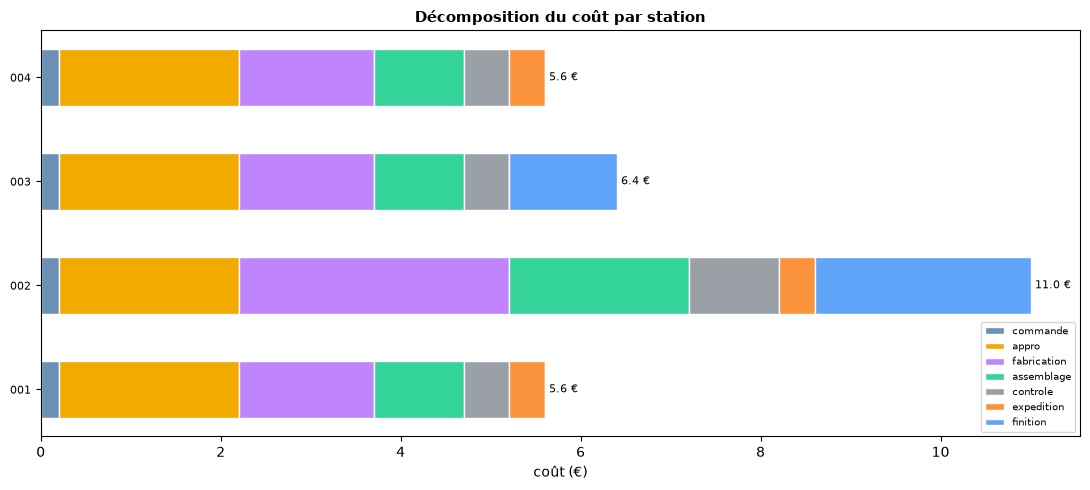

In [22]:
# Coûts empilés par station — voir où se concentre la valeur ajoutée
viz.dessiner_couts(resultats_t1b)
plt.show()


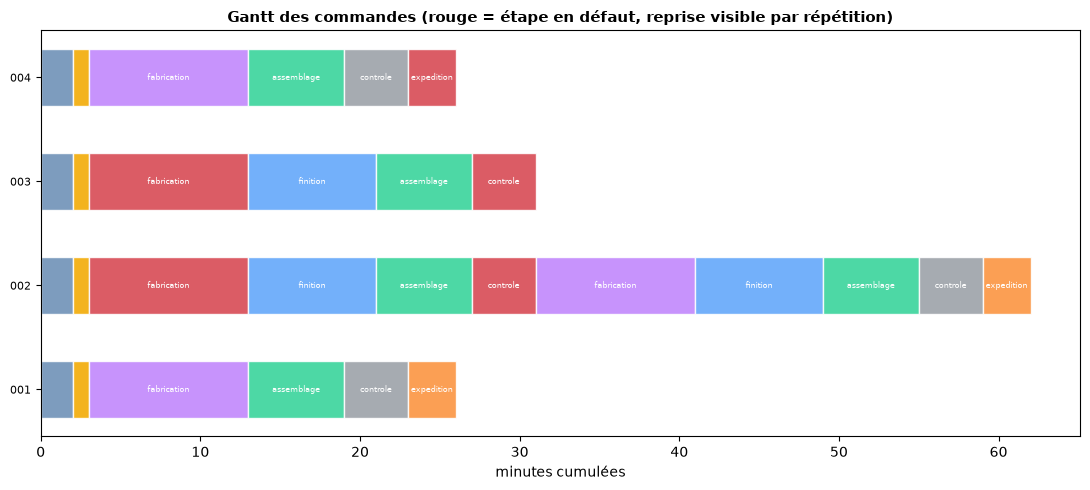

In [23]:
# Gantt par commande — durée par étape, les reprises (rework) sont visibles
viz.dessiner_gantt(resultats_t1b)
plt.show()


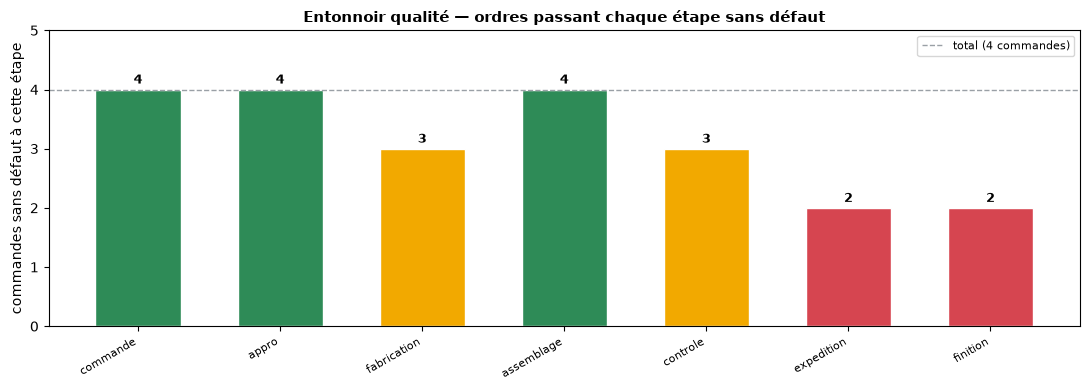

In [24]:
# Entonnoir : taux de passage par station (combien atteignent l'expédition ?)
viz.dessiner_entonnoir(resultats_t1b)
plt.show()


---

## 🔧 Activité — votre code ici


**But.** Ajouter une station **emballage cadeau** au graphe (option Premium, comme dans NB_T2a).

1. Écrire un nœud `n_emballage(s)` qui appelle une simulation et renvoie un `defaut` éventuel.
2. L'insérer **entre `assemblage` et `controle`**, uniquement pour la gamme Premium (ou pour tous).
3. Relancer sur CMD-002 et vérifier que le graphe passe bien par `emballage`.


In [25]:
# 👉 À vous.
# def n_emballage(s):
#     r = ...  # simuler un défaut d'emballage éventuel
#     return {"defauts": s["defauts"] + ([r["defaut"]] if r["defaut"] else []),
#             "historique": [noter_etape("emballage", r)]}
#
# TODO : copier construire_graphe, insérer le nœud 'emballage' entre assemblage et controle, recompiler.
print("Squelette prêt — insérer n_emballage entre 'assemblage' et 'controle'.")


Squelette prêt — insérer n_emballage entre 'assemblage' et 'controle'.


### 🧭 Ce qu'on a construit vs la production

| Brique de ce notebook | Équivalent production |
|---|---|
| `StateGraph` en mémoire | LangGraph Server / LangSmith Deployment (API, scaling, cron) |
| `MemorySaver` | checkpointer PostgreSQL (état durable, reprise après crash) |
| `interrupt`/`Command(resume)` | file d'attente HITL + UI de validation |
| `print()` | tracing **LangSmith** (chaque nœud/appel visible, éval) |
| modèle en dur | routage multi-modèles / multi-provider (agnostique) |

### 🧭 Mistral Workflows ↔ LangGraph — la comparaison honnête

| | **Mistral Workflows** (NB_T2a) | **LangGraph** (ce notebook) |
|---|---|---|
| Modèle | exécution durable **event-sourcing** (Temporal) | graphe d'état + **checkpointer** (super-steps) |
| Écriture | Python **impératif** (`@activity`/`@workflow`) | graphe **déclaratif** (`add_node`/`add_edge`) |
| Durabilité | native (reprise au dernier step, retries par activité) | via checkpointer + `RetryPolicy` par nœud ; **peut aussi tourner sur Temporal** |
| Routage | handoffs décidés par le modèle **ou** code du workflow | **arêtes conditionnelles** déclarées (déterministe, auditable) |
| Couplage | intégré Mistral (Studio, connecteurs) | **agnostique** (tout provider, dont Mistral) |
| Licence / maturité | SDK propriétaire, **preview** | **MIT**, **1.0 GA** |

**À retenir.** Ni supérieur ni inférieur : **deux moteurs de la même famille**. Workflows brille en
durabilité industrielle intégrée et pauses longues ; LangGraph en **flot de contrôle explicite,
open-source et model-agnostique**. On peut même **composer** (LangGraph sur des modèles Mistral, voire
sur Temporal). Souveraineté + auditabilité → LangGraph sur Mistral self-hébergé.

### 🚀 Pour aller plus loin
- **NB_T2a** — la même usine en **Mistral Workflows** (exécution durable, `wait_for_input`).
- **À vous.** Brancher **LangSmith** (`LANGSMITH_TRACING=true`) et observer chaque nœud du graphe.


---

### 📚 Pour aller plus loin

- **LangGraph** — docs.langchain.com/oss/python/langgraph : StateGraph, persistence, interrupt, RetryPolicy.- **ReAct** — Yao et al. (2022) arXiv:2210.03629 : raisonnement + action interfoliés (agent de la Task 1).- **Temporal ↔ LangGraph** — intégration officielle : exécuter un graphe LangGraph en durable sur Temporal.
> 🗂️ Références complètes de la formation :
> [`ressources/references_academiques.md`](../../ressources/references_academiques.md).
